In [1]:
!pip install transformers datasets scikit-learn sentencepiece

In [2]:
from google.colab import files
uploaded = files.upload()

Saving kannada_offensive_dev.csv to kannada_offensive_dev.csv
Saving kannada_offensive_test.csv to kannada_offensive_test.csv
Saving kannada_offensive_train.csv to kannada_offensive_train.csv


In [3]:
import pandas as pd

train = pd.read_csv("kannada_offensive_train.csv", sep="\t", header=None, engine='python', on_bad_lines='skip')
dev   = pd.read_csv("kannada_offensive_dev.csv",   sep="\t", header=None, engine='python', on_bad_lines='skip')
test  = pd.read_csv("kannada_offensive_test.csv",  sep="\t", header=None, engine='python', on_bad_lines='skip')

train.columns = ["text", "label"]
dev.columns   = ["text", "label"]
test.columns  = ["text", "label"]

In [4]:
def convert_label(label):
    return 0 if label == "Not_offensive" else 1

train['label'] = train['label'].apply(convert_label)
dev['label']   = dev['label'].apply(convert_label)
test['label']  = test['label'].apply(convert_label)

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

train_encodings = tokenizer(list(train['text']), truncation=True, padding=True, max_length=128)
val_encodings   = tokenizer(list(dev['text']),   truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(list(test['text']),  truncation=True, padding=True, max_length=128)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
import torch

class AbuseDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = AbuseDataset(train_encodings, train['label'])
val_dataset   = AbuseDataset(val_encodings, dev['label'])
test_dataset  = AbuseDataset(test_encodings, test['label'])

In [7]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [14]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [15]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.632252,0.610608,0.689433,0.622848,0.688581,0.568571
2,0.592563,0.599090,0.712629,0.645469,0.727599,0.580000
3,0.593068,0.640454,0.692010,0.566243,0.776119,0.445714
4,0.523145,0.552868,0.738402,0.718447,0.698113,0.740000
5,0.512025,0.549204,0.746134,0.704648,0.741325,0.671429


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3885, training_loss=0.5691857611657416, metrics={'train_runtime': 788.346, 'train_samples_per_second': 39.418, 'train_steps_per_second': 4.928, 'total_flos': 2044044011328000.0, 'train_loss': 0.5691857611657416, 'epoch': 5.0})

In [16]:
trainer.evaluate(test_dataset)

{'eval_loss': 0.5248018503189087,
 'eval_accuracy': 0.767052767052767,
 'eval_f1': 0.7286356821589205,
 'eval_precision': 0.7689873417721519,
 'eval_recall': 0.6923076923076923,
 'eval_runtime': 1.726,
 'eval_samples_per_second': 450.18,
 'eval_steps_per_second': 56.78,
 'epoch': 5.0}

In [17]:
trainer.save_model("my_model")
tokenizer.save_pretrained("my_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_model/tokenizer_config.json', 'my_model/tokenizer.json')

In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model = AutoModelForSequenceClassification.from_pretrained("my_model")
tokenizer = AutoTokenizer.from_pretrained("my_model")

model.eval()   # important

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=2, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [24]:
print(train['label'].value_counts())

label
0    3543
1    2672
Name: count, dtype: int64


In [26]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [28]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train['label']),
    y=train['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([0.8771, 1.1630])


In [29]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [30]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [32]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)   # move model to GPU

text = "This is a nice message"

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

# 🔥 MOVE INPUTS TO GPU
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

probs = F.softmax(outputs.logits, dim=1)

off_prob = probs[0][1].item()

label = "Offensive 🚨" if off_prob > 0.6 else "Not Offensive ✅"

print("Offensive Probability:", off_prob)
print("Prediction:", label)

Offensive Probability: 0.8975674510002136
Prediction: Offensive 🚨


In [33]:
texts = [
    "hello how are you",
    "good job",
    "nice work",
    "tumba chennagide",
    "you are bad",
    "you are useless",
]

for text in texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    print(text)
    print("Not Offensive:", round(probs[0][0].item(), 3),
          "Offensive:", round(probs[0][1].item(), 3))
    print()

hello how are you
Not Offensive: 0.104 Offensive: 0.896

good job
Not Offensive: 0.112 Offensive: 0.888

nice work
Not Offensive: 0.116 Offensive: 0.884

tumba chennagide
Not Offensive: 0.864 Offensive: 0.136

you are bad
Not Offensive: 0.101 Offensive: 0.899

you are useless
Not Offensive: 0.101 Offensive: 0.899



In [34]:
extra_data = pd.DataFrame({
    "text": [
        "hello how are you",
        "good job",
        "nice work",
        "well done",
        "great work bro",
        "you did good",
        "awesome work",
        "keep it up",
        "very nice",
        "super work"
    ],
    "label": [0]*10
})

train = pd.concat([train, extra_data]).reset_index(drop=True)

In [35]:
train = train.sample(frac=1).reset_index(drop=True)

In [36]:
extra_data2 = pd.DataFrame({
    "text": [
        "tumba good work",
        "very chennagide",
        "nice maga",
        "super bro",
    ],
    "label": [0]*4
})

train = pd.concat([train, extra_data2]).reset_index(drop=True)

In [37]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

train_encodings = tokenizer(list(train['text']), truncation=True, padding=True, max_length=128)
val_encodings   = tokenizer(list(dev['text']),   truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(list(test['text']),  truncation=True, padding=True, max_length=128)

In [38]:
import torch

class AbuseDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = AbuseDataset(train_encodings, train['label'])
val_dataset   = AbuseDataset(val_encodings, dev['label'])
test_dataset  = AbuseDataset(test_encodings, test['label'])

In [39]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train['label']),
    y=train['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([0.8756, 1.1656])


In [40]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [41]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=7,
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [49]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):  # 🔥 MUST HAVE **kwargs
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [43]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [50]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [51]:
trainer.train(resume_from_checkpoint=True)

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
5,0.512025,0.581742,0.733247,0.655574,0.784861,0.562857
6,0.521507,0.599913,0.742268,0.693252,0.748344,0.645714
7,0.494751,0.594140,0.743557,0.702541,0.736677,0.671429


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=5453, training_loss=0.14490675248510354, metrics={'train_runtime': 483.3379, 'train_samples_per_second': 90.212, 'train_steps_per_second': 11.282, 'total_flos': 2868568281062400.0, 'train_loss': 0.14490675248510354, 'epoch': 7.0})

In [53]:
trainer.evaluate(test_dataset)

{'eval_loss': 0.5304645299911499,
 'eval_accuracy': 0.7657657657657657,
 'eval_f1': 0.7250755287009063,
 'eval_precision': 0.7717041800643086,
 'eval_recall': 0.6837606837606838,
 'eval_runtime': 3.2704,
 'eval_samples_per_second': 237.583,
 'eval_steps_per_second': 29.965,
 'epoch': 7.0}

In [55]:
trainer.save_model("my_model")
tokenizer.save_pretrained("my_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_model/tokenizer_config.json', 'my_model/tokenizer.json')

In [56]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model = AutoModelForSequenceClassification.from_pretrained("my_model")
tokenizer = AutoTokenizer.from_pretrained("my_model")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=2, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [59]:
while True:
    text = input("\nEnter text (or type 'exit'): ")

    if text.lower() == "exit":
        break

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    not_off = probs[0][0].item()
    off = probs[0][1].item()

    label = "Offensive 🚨" if off > 0.6 else "Not Offensive ✅"

    print(f"Prediction: {label} (Offensive prob: {off:.2f})")


Enter text (or type 'exit'): Movie tumba chenagithu
Prediction: Not Offensive ✅ (Offensive prob: 0.24)

Enter text (or type 'exit'): movie changi irlilla
Prediction: Not Offensive ✅ (Offensive prob: 0.18)

Enter text (or type 'exit'): movie kachada ithu
Prediction: Not Offensive ✅ (Offensive prob: 0.24)

Enter text (or type 'exit'): maga you are waste
Prediction: Offensive 🚨 (Offensive prob: 0.90)

Enter text (or type 'exit'): maga you are waste
Prediction: Offensive 🚨 (Offensive prob: 0.90)

Enter text (or type 'exit'): exit


In [64]:
texts = [
    # ❗ Mild → Moderate
    "you are tumba useless",
    "ivnu very bad fellow",
    "maga you are waste",
    "this guy tumba irritating",
    "you don't know anything maga",
    "very useless person ivnu",

    # ❗ Moderate → Strong
    "you are stupid maga",
    "ivnu full nonsense",
    "tumba worst person you are",
    "you are total waste fellow",
    "ivnu brain illa fellow",
    "this guy is damn useless",

    # ❗ Strong
    "you are bloody useless maga",
    "ivnu worst fellow ever",
    "shut up maga you are dumb",
    "tumba cheap behaviour yours",
    "you are such an idiot maga",

    # ✅ Non-offensive
    "tumba chennagide",
    "very nice maga",
    "good work bro",
    "you did great",
    "super work guru"
#mix
    "you are tumba useless",
    "ivnu very bad fellow",
    "maga you are waste",
    "you are stupid maga",
    "ivnu full nonsense",
    "hello how are you",
    "good job",
    "tumba chennagide"
]

# Tokenize
inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=128)
inputs = {k: v.to(device) for k, v in inputs.items()}

# Predict
with torch.no_grad():
    outputs = model(**inputs)

# Convert to probabilities
probs = F.softmax(outputs.logits, dim=1)

# Print results
for i, text in enumerate(texts):
    not_off = probs[i][0].item()
    off = probs[i][1].item()

    # 🔥 threshold (important)
    label = "Offensive 🚨" if off > 0.6 else "Not Offensive ✅"

    print(f"\nText: {text}")
    print(f"Not Offensive: {not_off:.3f}")
    print(f"Offensive: {off:.3f}")
    print(f"Prediction: {label}")


Text: you are tumba useless
Not Offensive: 0.105
Offensive: 0.895
Prediction: Offensive 🚨

Text: ivnu very bad fellow
Not Offensive: 0.604
Offensive: 0.396
Prediction: Not Offensive ✅

Text: maga you are waste
Not Offensive: 0.104
Offensive: 0.896
Prediction: Offensive 🚨

Text: this guy tumba irritating
Not Offensive: 0.121
Offensive: 0.879
Prediction: Offensive 🚨

Text: you don't know anything maga
Not Offensive: 0.257
Offensive: 0.743
Prediction: Offensive 🚨

Text: very useless person ivnu
Not Offensive: 0.488
Offensive: 0.512
Prediction: Not Offensive ✅

Text: you are stupid maga
Not Offensive: 0.114
Offensive: 0.886
Prediction: Offensive 🚨

Text: ivnu full nonsense
Not Offensive: 0.729
Offensive: 0.271
Prediction: Not Offensive ✅

Text: tumba worst person you are
Not Offensive: 0.170
Offensive: 0.830
Prediction: Offensive 🚨

Text: you are total waste fellow
Not Offensive: 0.104
Offensive: 0.896
Prediction: Offensive 🚨

Text: ivnu brain illa fellow
Not Offensive: 0.816
Offensive: 0

In [65]:
extra_non_offensive = pd.DataFrame({
    "text": [
        "hello how are you",
        "good job",
        "nice work",
        "you did great",
        "well done",
        "great work",
        "awesome work",
        "keep it up",
        "very good",
        "excellent work"
    ],
    "label": [0]*10
})

In [66]:
extra_offensive = pd.DataFrame({
    "text": [
        "ivnu useless",
        "ivnu worst",
        "ivnu brain illa",
        "ivnu waste fellow",
        "tumba useless ivnu",
        "ivnu nonsense",
        "maga useless fellow"
    ],
    "label": [1]*7
})

In [67]:
train = pd.concat([train, extra_non_offensive, extra_offensive]).reset_index(drop=True)
train = train.sample(frac=1).reset_index(drop=True)

In [68]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=8,   # 🔥 increased (7–8 both fine)
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [69]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [70]:
trainer.train(resume_from_checkpoint=True)

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
8,0.486518,0.603566,0.738402,0.701031,0.723404,0.680000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=6232, training_loss=0.06127877718983015, metrics={'train_runtime': 170.384, 'train_samples_per_second': 292.469, 'train_steps_per_second': 36.576, 'total_flos': 3278297972021760.0, 'train_loss': 0.06127877718983015, 'epoch': 8.0})

In [71]:
trainer.evaluate(test_dataset)

{'eval_loss': 0.5304758548736572,
 'eval_accuracy': 0.7657657657657657,
 'eval_f1': 0.7259036144578314,
 'eval_precision': 0.7699680511182109,
 'eval_recall': 0.6866096866096866,
 'eval_runtime': 1.7766,
 'eval_samples_per_second': 437.358,
 'eval_steps_per_second': 55.162,
 'epoch': 8.0}

In [72]:
trainer.save_model("my_model")
tokenizer.save_pretrained("my_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_model/tokenizer_config.json', 'my_model/tokenizer.json')

In [75]:
while True:
    text = input("\nEnter text (or type 'exit'): ")

    if text.lower() == "exit":
        break

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    not_off = probs[0][0].item()
    off = probs[0][1].item()

    label = "Offensive 🚨" if off > 0.6 else "Not Offensive ✅"

    print(f"Prediction: {label} (Offensive prob: {off:.2f})")


Enter text (or type 'exit'): movie tumba chenagithu
Prediction: Not Offensive ✅ (Offensive prob: 0.24)

Enter text (or type 'exit'): movie ge hogidu waste
Prediction: Offensive 🚨 (Offensive prob: 0.89)

Enter text (or type 'exit'): you are tumba useless maga
Prediction: Not Offensive ✅ (Offensive prob: 0.44)

Enter text (or type 'exit'): you are tumba useless maga
Prediction: Not Offensive ✅ (Offensive prob: 0.44)

Enter text (or type 'exit'): ivnu full nonsense fellow
Prediction: Not Offensive ✅ (Offensive prob: 0.27)

Enter text (or type 'exit'): ivnu full nonsense fellow
Prediction: Not Offensive ✅ (Offensive prob: 0.27)

Enter text (or type 'exit'): tumba worst behaviour yours
Prediction: Offensive 🚨 (Offensive prob: 0.79)

Enter text (or type 'exit'): tumba chennagide bro
Prediction: Not Offensive ✅ (Offensive prob: 0.13)

Enter text (or type 'exit'): very nice maga good work
Prediction: Offensive 🚨 (Offensive prob: 0.88)

Enter text (or type 'exit'): super work guru well done
Pr

In [77]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model = AutoModelForSequenceClassification.from_pretrained("my_model")
tokenizer = AutoTokenizer.from_pretrained("my_model")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=2, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [78]:
extra_fix = pd.DataFrame({
    "text": [
        "you are useless maga",
        "ivnu nonsense fellow",
        "very nice maga good work",
        "nice maga",
        "good maga"
    ],
    "label": [1, 1, 0, 0, 0]
})

train = pd.concat([train, extra_fix]).reset_index(drop=True)


In [79]:
train = pd.concat([train, extra_non_offensive, extra_offensive]).reset_index(drop=True)
train = train.sample(frac=1).reset_index(drop=True)

In [81]:
train_encodings = tokenizer(list(train['text']), truncation=True, padding=True, max_length=128)

In [82]:
train_dataset = AbuseDataset(train_encodings, train['label'])

In [83]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=3e-5,              # 🔥 improved
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,   # 🔥 better learning
    num_train_epochs=8,
    warmup_ratio=0.1,                # 🔥 important
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    fp16=True
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [84]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)
trainer.train(resume_from_checkpoint=True)

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Epoch,Training Loss,Validation Loss


TrainOutput(global_step=6232, training_loss=0.0, metrics={'train_runtime': 2.9286, 'train_samples_per_second': 17182.209, 'train_steps_per_second': 1076.278, 'total_flos': 3278297972021760.0, 'train_loss': 0.0, 'epoch': 8.0})

In [85]:
trainer.evaluate(test_dataset)

{'eval_loss': 0.5304758548736572,
 'eval_accuracy': 0.7657657657657657,
 'eval_f1': 0.7259036144578314,
 'eval_precision': 0.7699680511182109,
 'eval_recall': 0.6866096866096866,
 'eval_runtime': 1.6798,
 'eval_samples_per_second': 462.554,
 'eval_steps_per_second': 58.34,
 'epoch': 8.0}

In [86]:
trainer.save_model("my_model")
tokenizer.save_pretrained("my_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_model/tokenizer_config.json', 'my_model/tokenizer.json')

In [96]:
while True:
    text = input("\nEnter text (or type 'exit'): ")

    if text.lower() == "exit":
        break

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    not_off = probs[0][0].item()
    off = probs[0][1].item()

    label = "Offensive 🚨" if off > 0.6 else "Not Offensive ✅"

    print(f"Prediction: {label} (Offensive prob: {off:.2f})")



Enter text (or type 'exit'): movie tumba chenagide
Prediction: Not Offensive ✅ (Offensive prob: 0.10)

Enter text (or type 'exit'): movie ge hogide waste
Prediction: Offensive 🚨 (Offensive prob: 0.89)

Enter text (or type 'exit'): ohh avna handle madadu tumba kashta
Prediction: Offensive 🚨 (Offensive prob: 0.63)

Enter text (or type 'exit'): avlu tumba hardwork madtidale
Prediction: Not Offensive ✅ (Offensive prob: 0.41)

Enter text (or type 'exit'): thank god avnu sathu hogilla
Prediction: Not Offensive ✅ (Offensive prob: 0.47)

Enter text (or type 'exit'):  you are tumba useless
Prediction: Offensive 🚨 (Offensive prob: 0.89)

Enter text (or type 'exit'): super work guru
Prediction: Not Offensive ✅ (Offensive prob: 0.10)

Enter text (or type 'exit'): maga you are waste
Prediction: Offensive 🚨 (Offensive prob: 0.90)

Enter text (or type 'exit'):  you are stupid maga
Prediction: Offensive 🚨 (Offensive prob: 0.89)

Enter text (or type 'exit'): exit


In [97]:
trainer.save_model("my_model")
tokenizer.save_pretrained("my_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_model/tokenizer_config.json', 'my_model/tokenizer.json')

In [98]:
!zip -r my_model.zip my_model

  adding: my_model/ (stored 0%)
  adding: my_model/model.safetensors (deflated 25%)
  adding: my_model/training_args.bin (deflated 53%)
  adding: my_model/tokenizer.json (deflated 77%)
  adding: my_model/config.json (deflated 52%)
  adding: my_model/tokenizer_config.json (deflated 48%)


In [100]:
model.save_pretrained("final_model")
tokenizer.save_pretrained("final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('final_model/tokenizer_config.json', 'final_model/tokenizer.json')

In [102]:
!zip -r final_checkpoint.zip results/checkpoint-6232

  adding: results/checkpoint-6232/ (stored 0%)
  adding: results/checkpoint-6232/scaler.pt (deflated 64%)
  adding: results/checkpoint-6232/model.safetensors (deflated 25%)
  adding: results/checkpoint-6232/trainer_state.json (deflated 73%)
  adding: results/checkpoint-6232/training_args.bin (deflated 53%)
  adding: results/checkpoint-6232/scheduler.pt (deflated 62%)
  adding: results/checkpoint-6232/config.json (deflated 52%)
  adding: results/checkpoint-6232/rng_state.pth (deflated 26%)
  adding: results/checkpoint-6232/optimizer.pt (deflated 69%)


In [103]:
!zip -r final_model.zip final_model

  adding: final_model/ (stored 0%)
  adding: final_model/model.safetensors (deflated 25%)
  adding: final_model/tokenizer.json (deflated 77%)
  adding: final_model/config.json (deflated 52%)
  adding: final_model/tokenizer_config.json (deflated 48%)


In [104]:
from google.colab import files
files.download("final_model.zip")
files.download("final_checkpoint.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:
preds = trainer.predict(test_dataset)

In [107]:
import numpy as np

y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

In [108]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Not Offensive", "Offensive"]))

               precision    recall  f1-score   support

Not Offensive       0.76      0.83      0.80       426
    Offensive       0.77      0.69      0.73       351

     accuracy                           0.77       777
    macro avg       0.77      0.76      0.76       777
 weighted avg       0.77      0.77      0.76       777



In [109]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[354  72]
 [110 241]]


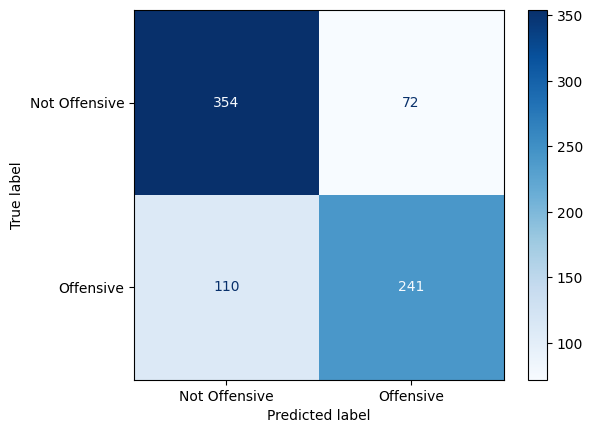

In [110]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Offensive", "Offensive"])
disp.plot(cmap="Blues")
plt.show()

In [111]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Not Offensive", "Offensive"]))

print("\nConfusion Matrix:\n")
print(cm)


Classification Report:

               precision    recall  f1-score   support

Not Offensive       0.76      0.83      0.80       426
    Offensive       0.77      0.69      0.73       351

     accuracy                           0.77       777
    macro avg       0.77      0.76      0.76       777
 weighted avg       0.77      0.77      0.76       777


Confusion Matrix:

[[354  72]
 [110 241]]
